In [ ]:
# for different cost factors at 0.95 lower bound 1

# open file

import pickle
import functions as func
from importlib import reload
reload(func)

with open('N_16/higher_costs_ftol_1.pickle', 'rb') as f:
    data = pickle.load(f)
    
# plot the data 
cost_factors = list(range(5, 101, 5))
legend_label = "Factor"
alphas = [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
    
func.plot_all_kj(2**16, data[-1], cost_factors, legend_label, 0.95)

In [30]:
from math import pi, sqrt
from statistics import NormalDist

# okay lets now find the default line 
# [K_js, m_0, final_cost, m_values]
# Kj's all 1
kjs = [1 for _ in range(80)]

#Calculate the m_t for the predicted curves
def calculate_m_t(N, t, predicted_curve):
    mt_target = N**(2/3) # our target mt
    m_0 = round(mt_target/(1-0.95))    # our starting m_0
    m = m_0  # initial value of m
    
    for i in range(0, t):# iterate through the column
        # calculate k -> k has to be at least 1
        k = max(predicted_curve[i], 1)
        
        # Calculate E1 and E2
        E1 = (1-1/N) ** m
        E2 = (1-2/N) ** m
        average = N*(1 - E1)
        
        # check if the variance is positive, sometimes error happens because of float calculation on very small values
        if N*((N-1)*E2 + E1 - N*E1**2)<0:
            # if it is negative (error), set it to 0
            variance = 0
        else:
            # count the statistical variance of m_j+1 otherwise
            variance = sqrt(N*((N-1)*E2 + E1 - N*E1**2))
            
        # find the m_j+1
        m = average + NormalDist().inv_cdf((k - pi / 8) / (k - pi / 4 + 1)) * variance
        
    # return the final m_t
    return m

# calculate vanilla m_t
v_mt = calculate_m_t(2**16, 80, kjs)
print(v_mt)

1541.392961175683


In [42]:
# now add this to the plot

import matplotlib.pyplot as plt
import seaborn as sns

# constants for plotting
NUM_COLORS = 20
LINE_STYLES = ['solid', 'dashed', 'dashdot', 'dotted']
NUM_STYLES = len(LINE_STYLES)

def plott(results, labels, legend_label, vanilla):

    # to get different colours
    sns.reset_orig()  # get default matplotlib styles back
    clrs = sns.color_palette('husl', n_colors=NUM_COLORS)  # a list of RGB tuples

    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(1, 1, 1)
    
    # plot baseline
    K_js = vanilla[0]
    baseline, = ax.plot(K_js, label=f"{legend_label} = baseline", color='k', linestyle='--')
    # lines[0].set_linestyle(LINE_STYLES[i % NUM_STYLES])

    # annotate the m_t value for each line in the plot
    ax.annotate(round(vanilla[-1]),
                xy=(1, 1),
                xytext=(6, 0),
                color='k',
                xycoords=ax.get_yaxis_transform(), textcoords="offset points", size=8, va="center")

    # [K_js, m_0, final_cost, m_values]
    for i, result in enumerate(results):
        K_js = result[0]
        label = labels[i]
        lines = ax.plot(K_js, label=f"{legend_label} = {label}")
        lines[0].set_color(clrs[i])
        lines[0].set_linestyle(LINE_STYLES[i % NUM_STYLES])

        # annotate the m_t value for each line in the plot
        y = result[0][-1]  # get the last K_j value to position text

        ax.annotate(round(result[3][-1]),
                    xy=(1, y),
                    xytext=(6, 0),
                    color=clrs[i],
                    xycoords=ax.get_yaxis_transform(), textcoords="offset points", size=8, va="center")

    ax.set_ylabel(r"$K_{j}$", **{"fontname": "Times New Roman", "style": "italic", "fontsize": 12, "labelpad": -2})
    ax.set_xlabel("j", **{"fontname": "Times New Roman", "style": "italic", "fontsize": 12})

    # Create a single legend from the first subplot
    legend_lines = [baseline] + [plt.Line2D([0], [0], color=clrs[i], linestyle=LINE_STYLES[i % NUM_STYLES]) for i in range(20)]
    labels = ['1'] + labels

    fig.legend(legend_lines, labels, loc="center left", title=legend_label, bbox_to_anchor=(0.975, 0.5), fontsize='small')
    plt.show()
    
    
van_dat = [kjs, v_mt]
plott(data[-1], cost_factors, legend_label, van_dat)

IndexError: list index out of range

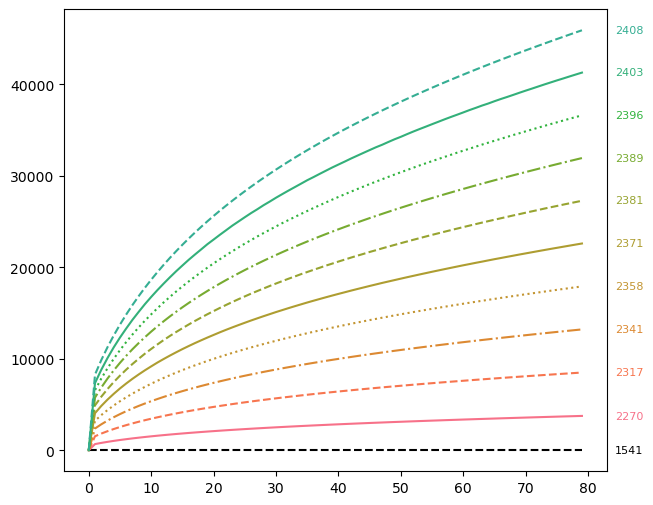

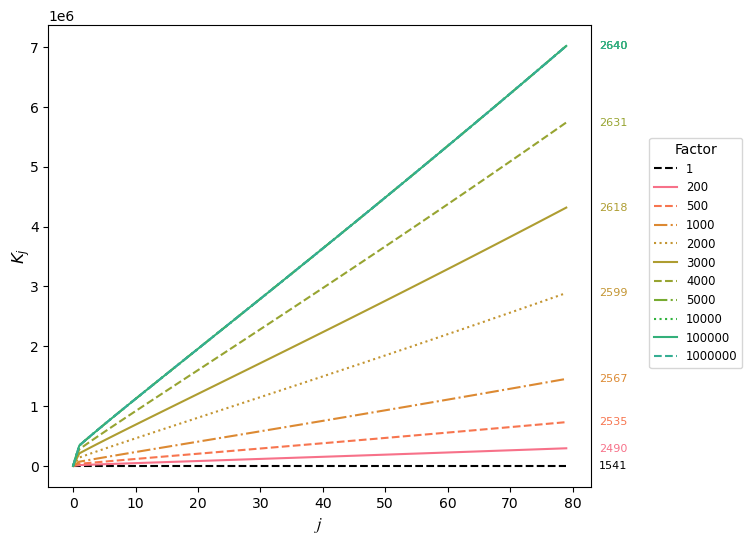

In [43]:
# import data for higher precomp
with open('N_16/much_higher_precomp/lower_bound_7_higher_cost_t_80_curves.pickle', 'rb') as f:
    dat_h = pickle.load(f)
    
cost_factors = [200, 500, 1000, 2000, 3000, 4000, 5000, 10000, 100000, 1000000]
    
plott(dat_h, cost_factors, legend_label, van_dat)